# Лабораторная работа №2: Обнаружение выбросов в данных
## Цель работы
1. Освоить методы обнаружения выбросов на основе статистических критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом предметной области.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, norm, gmean
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Задание 1. Загрузка и профилирование данных

In [36]:
# Загрузка датасета
df = pd.read_csv('../data/SDnobel.csv', sep=';')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

# Информация о датасете
df.info()
df.describe()

# Анализ пропусков
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_table = pd.DataFrame({
    'Количество пропусков': missing_data,
    'Доля (%)': missing_percent
})
print("Пропуски по столбцам:")
print(missing_table[missing_table['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False))

# Очистка данных: удаляем строки без возраста (организации)
df_clean = df.dropna(subset=['age']).copy()
print(f"\nПосле удаления строк без возраста: {len(df_clean)} записей")

Размер датасета: 911 строк, 23 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Column1               911 non-null    int64  
 1   year                  911 non-null    int64  
 2   category              911 non-null    str    
 3   prize                 911 non-null    str    
 4   prize_share           911 non-null    str    
 5   laureate_id           911 non-null    int64  
 6   laureate_type         911 non-null    str    
 7   full_name             911 non-null    str    
 8   birth_date            883 non-null    str    
 9   birth_city            883 non-null    str    
 10  birth_country         885 non-null    str    
 11  sex                   885 non-null    str    
 12  organization_name     665 non-null    str    
 13  organization_city     667 non-null    str    
 14  organization_country  667 non-null    str    

## Визуальный анализ числовых признаков

Выберем два признака для анализа:
- **age** (возраст лауреата) - основной числовой признак
- **year** (год присуждения премии) - временной признак

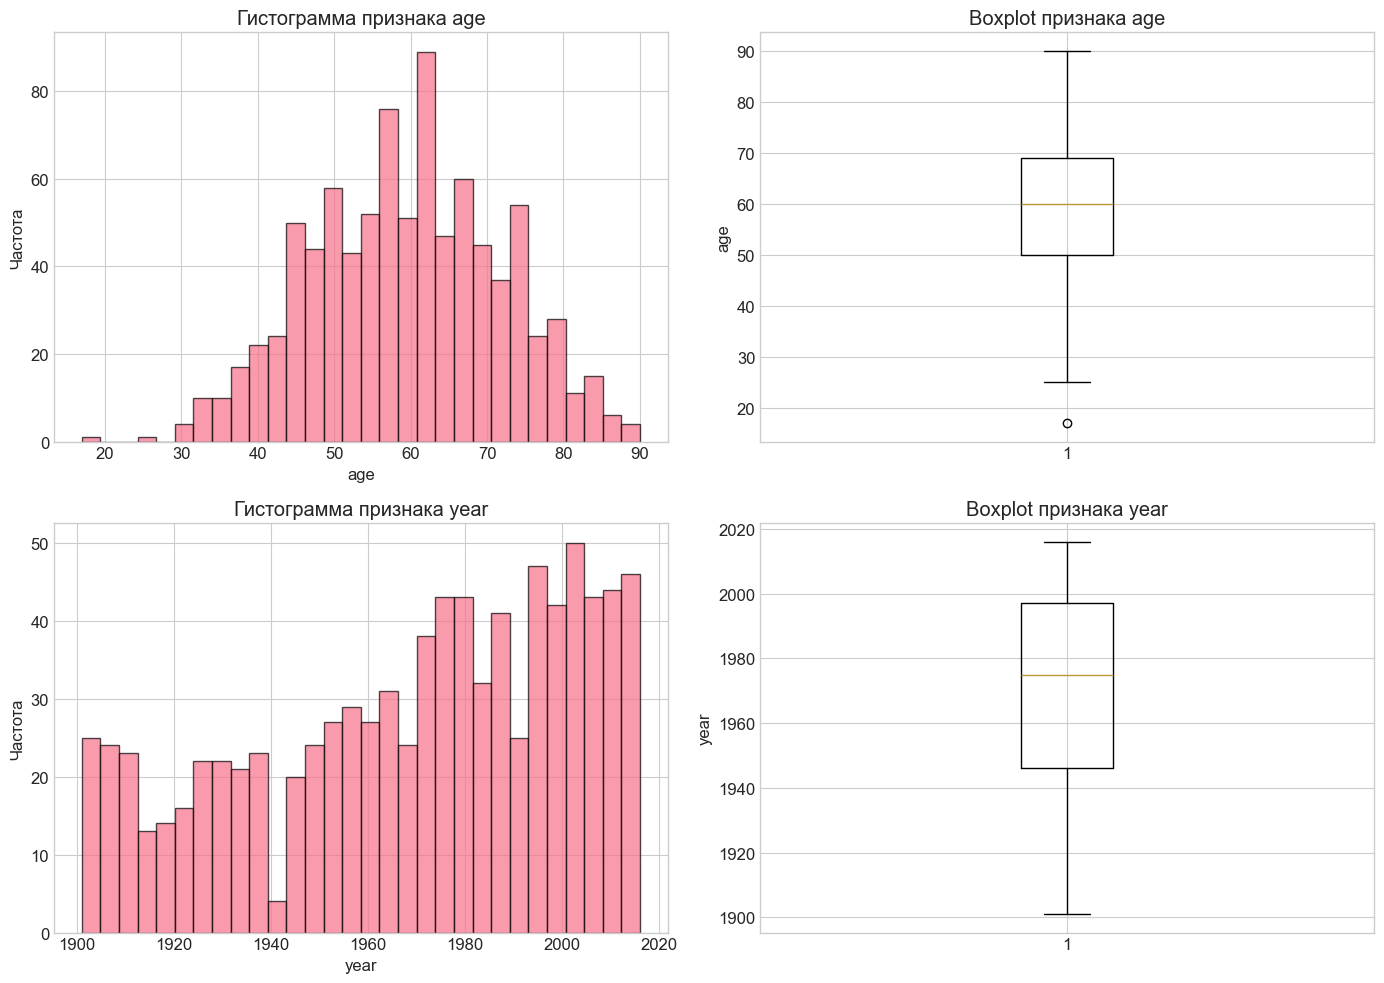

Анализ экстремальных значений:

Возраст (age):
  Минимум: 17.0 лет
  Максимум: 90.0 лет
  Молодые лауреаты (<25 лет): 1 человек
  Пожилые лауреаты (>85 лет): 10 человек

Год (year):
  Диапазон: 1901 - 2016
  Количество уникальных лет: 113


In [12]:
# Выбор признаков для анализа
features_for_analysis = ['age', 'year']

# Создаем подграфики для гистограмм и boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_for_analysis):
    # Гистограмма
    axes[idx, 0].hist(df_clean[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Гистограмма признака {feature}')
    axes[idx, 0].set_xlabel(feature)
    axes[idx, 0].set_ylabel('Частота')
    
    # Boxplot
    axes[idx, 1].boxplot(df_clean[feature].dropna(), vert=True)
    axes[idx, 1].set_title(f'Boxplot признака {feature}')
    axes[idx, 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

# Анализ возможных выбросов
print("Анализ экстремальных значений:")
print(f"\nВозраст (age):")
print(f"  Минимум: {df_clean['age'].min():.1f} лет")
print(f"  Максимум: {df_clean['age'].max():.1f} лет")
print(f"  Молодые лауреаты (<25 лет): {len(df_clean[df_clean['age'] < 25])} человек")
print(f"  Пожилые лауреаты (>85 лет): {len(df_clean[df_clean['age'] > 85])} человек")

print(f"\nГод (year):")
print(f"  Диапазон: {df_clean['year'].min()} - {df_clean['year'].max()}")
print(f"  Количество уникальных лет: {df_clean['year'].nunique()}")

## Задание 2. Проверка нормальности распределения

Для признака **age** (возраст) выполним проверку нормальности распределения.

In [42]:
# Вычисление описательных характеристик
age_data = df_clean['age'].dropna()

mean_age = age_data.mean()
median_age = age_data.median()
std_age = age_data.std()
skewness_age = age_data.skew()
kurtosis_age = age_data.kurtosis()

print("Описательные характеристики признака 'age':")
print(f"Среднее: {mean_age:.2f} лет")
print(f"Медиана: {median_age:.2f} лет")
print(f"Стандартное отклонение: {std_age:.2f} ")
print(f"Коэффициент асимметрии (Skewness): {skewness_age:.3f}")
print(f"Коэффициент эксцесса (Kurtosis): {kurtosis_age:.3f}")

# Интерпретация
print("\nИнтерпретация:")
if abs(skewness_age) < 0.5:
    print("Асимметрия: распределение близко к симметричному")
elif skewness_age > 0:
    print(f"Асимметрия: правосторонняя (положительная) - {skewness_age:.3f}")
    print("  → 'хвост' распределения вытянут в сторону больших значений")
else:
    print(f"Асимметрия: левосторонняя (отрицательная) - {skewness_age:.3f}")

if kurtosis_age > 0:
    print(f"Эксцесс: островершинное распределение - {kurtosis_age:.3f}")
elif kurtosis_age < 0:
    print(f"Эксцесс: плосковершинное распределение - {kurtosis_age:.3f}")
else:
    print(f"Эксцесс: близок к нормальному - {kurtosis_age:.3f}")

Описательные характеристики признака 'age':
Среднее: 59.45 лет
Медиана: 60.00 лет
Стандартное отклонение: 12.40 
Коэффициент асимметрии (Skewness): -0.050
Коэффициент эксцесса (Kurtosis): -0.433

Интерпретация:
Асимметрия: распределение близко к симметричному
Эксцесс: плосковершинное распределение - -0.433


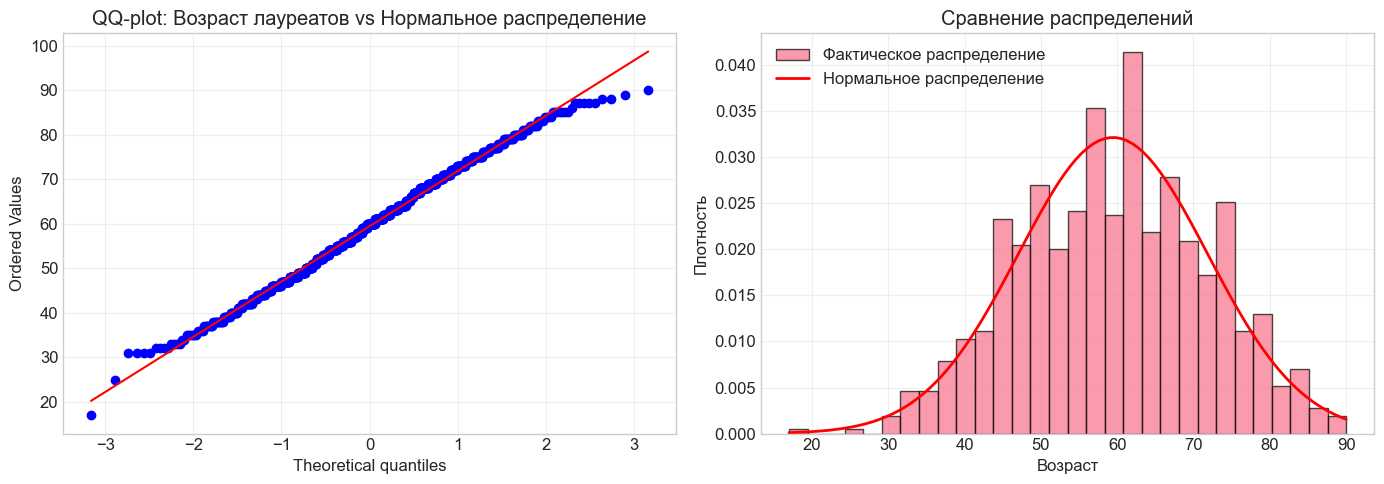

In [43]:
# Графический анализ - QQ-plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-plot
stats.probplot(age_data, dist="norm", plot=axes[0])
axes[0].set_title('QQ-plot: Возраст лауреатов vs Нормальное распределение')
axes[0].grid(True, alpha=0.3)

# Сравнение гистограммы с нормальной кривой
axes[1].hist(age_data, bins=30, density=True, alpha=0.7, edgecolor='black', label='Фактическое распределение')
x = np.linspace(age_data.min(), age_data.max(), 100)
axes[1].plot(x, norm.pdf(x, mean_age, std_age), 'r-', linewidth=2, label='Нормальное распределение')
axes[1].set_title('Сравнение распределений')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Плотность')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Вывод по графическому анализу:
- На QQ-plot точки не ложатся на прямую линию, особенно на концах распределения
- Гистограмма показывает правостороннюю асимметрию
- Распределение возраста Нобелевских лауреатов близко к нормальному, но всё же отличается от него

In [54]:
# Критерий Шапиро-Уилка
print("Критерий Шапиро-Уилка:")

statistic, p_value = shapiro(age_data)

print(f"Статистика теста: {statistic:.6f}")
print(f"P-value: {p_value:.6f}")
print(f"Уровень значимости α = 0.05")

print("\nФормулировка гипотез:")
print("H₀: выборка подчиняется нормальному распределению")
print("H₁: выборка не подчиняется нормальному распределению")

print("\nРезультат:")
if p_value > 0.05:
    print(f"p-value ({p_value:.6f}) > 0.05 → Нет оснований отвергнуть H₀")
    print("Вывод: распределение возраста можно считать нормальным")
else:
    print(f"p-value ({p_value:.6f}) < 0.05 → Отвергаем H₀")
    print("Вывод: распределение возраста НЕ является нормальным")

Критерий Шапиро-Уилка:
Статистика теста: 0.995043
P-value: 0.005711
Уровень значимости α = 0.05

Формулировка гипотез:
H₀: выборка подчиняется нормальному распределению
H₁: выборка не подчиняется нормальному распределению

Результат:
p-value (0.005711) < 0.05 → Отвергаем H₀
Вывод: распределение возраста НЕ является нормальным


## Задание 3. Обнаружение выбросов статистическими методами

Для признака **age** (возраст) применим методы Z-score и IQR.

In [55]:
# Метод Z-score
print("Метод Z-score:")

# Исходные данные
age_data = df_clean['age'].dropna()

# Расчёт Z-score
mean_age = age_data.mean()
std_age = age_data.std()
z_scores = (age_data - mean_age) / std_age

# Поиск выбросов (|Z| > 3)
outliers = age_data[np.abs(z_scores) > 3]
print(f"Найдено выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers_z)/len(age_data)*100:.2f}%")
print(f"Выбросы (Z-score): {sorted(outliers_z.values)}")

Метод Z-score:
Найдено выбросов: 1
Процент выбросов: 0.11%
Выбросы (Z-score): [np.float64(17.0)]


In [18]:
# Метод IQR
print("Метод IQR:")

Q1 = age_data.quantile(0.25)
Q3 = age_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = age_data[(age_data < lower_bound) | (age_data > upper_bound)]

print(f"Q1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers_iqr)}")
print(f"Процент выбросов: {len(outliers_iqr)/len(age_data)*100:.2f}%")
print(f"Выбросы (IQR): {sorted(outliers_iqr.values)}")

Метод IQR:
Q1 (25-й перцентиль): 50.00
Q3 (75-й перцентиль): 69.00
IQR: 19.00
Нижняя граница: 21.50
Верхняя граница: 97.50
Количество выбросов: 1
Процент выбросов: 0.11%
Выбросы (IQR): [np.float64(17.0)]


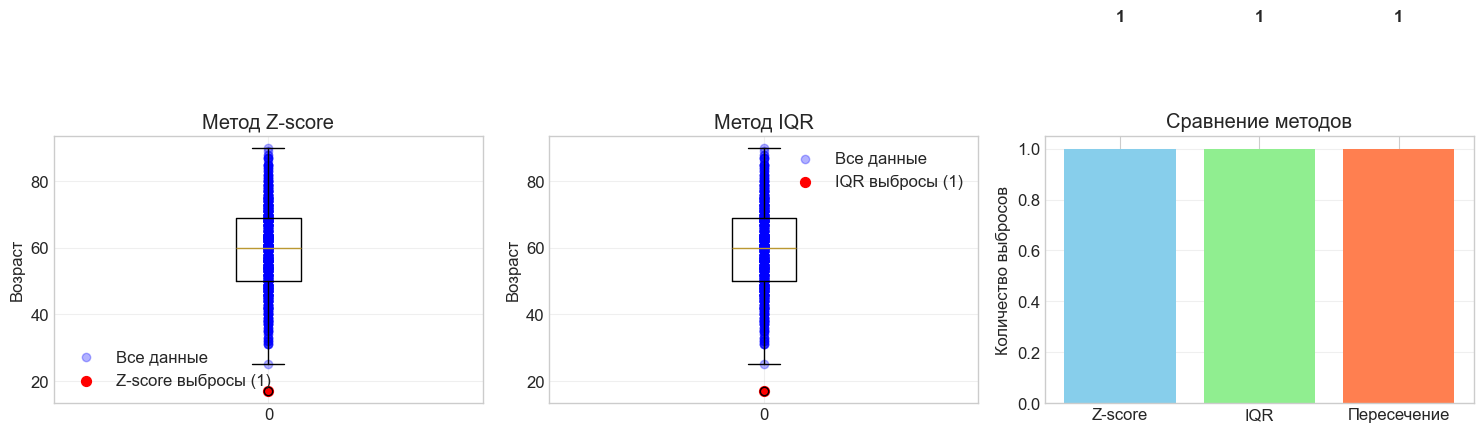

In [19]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Исходные данные с выделением выбросов по Z-score
axes[0].boxplot(age_data, vert=True, positions=[0])
axes[0].scatter([0]*len(age_data), age_data, alpha=0.3, c='blue', label='Все данные')
axes[0].scatter([0]*len(outliers_z), outliers_z, c='red', s=50, label=f'Z-score выбросы ({len(outliers_z)})')
axes[0].set_title('Метод Z-score')
axes[0].set_ylabel('Возраст')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Исходные данные с выделением выбросов по IQR
axes[1].boxplot(age_data, vert=True, positions=[0])
axes[1].scatter([0]*len(age_data), age_data, alpha=0.3, c='blue', label='Все данные')
axes[1].scatter([0]*len(outliers_iqr), outliers_iqr, c='red', s=50, label=f'IQR выбросы ({len(outliers_iqr)})')
axes[1].set_title('Метод IQR')
axes[1].set_ylabel('Возраст')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Сравнение методов
intersection = set(outliers_z) & set(outliers_iqr)
only_z = set(outliers_z) - set(outliers_iqr)
only_iqr = set(outliers_iqr) - set(outliers_z)

axes[2].bar(['Z-score', 'IQR', 'Пересечение'], 
            [len(outliers_z), len(outliers_iqr), len(intersection)], 
            color=['skyblue', 'lightgreen', 'coral'])
axes[2].set_title('Сравнение методов')
axes[2].set_ylabel('Количество выбросов')
axes[2].grid(True, alpha=0.3, axis='y')

for i, v in enumerate([len(outliers_z), len(outliers_iqr), len(intersection)]):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Сравнительный анализ методов

### Результаты

| Метод | Выбросы | Возраст |
|-------|---------|---------|
| Z-score | 1 | 17 лет |
| IQR | 1 | 17 лет |

### Что показали методы

Оба метода нашли один и тот же выброс — лауреата в возрасте 17 лет.

### Кто этот лауреат

- Имя: Malala Yousafzai
- Возраст: 17 лет
- Категория: Премия мира
- Год: 2014

### Почему это выброс

- Средний возраст лауреатов: 59.5 лет
- Медианный возраст: 60 лет
- 25% лауреатов моложе 50 лет
- 75% лауреатов старше 69 лет

Возраст 17 лет значительно отличается от всех остальных.

### Что делать с этим выбросом

| Вариант | Стоит ли делать | Почему |
|---------|-----------------|--------|
| Удалить | Нет | Это реальные данные, не ошибка |
| Оставить | Да | Это уникальный случай, важный для анализа |

### Вывод

Методы Z-score и IQR дали одинаковый результат. Это говорит о том, что выброс действительно аномальный. Удалять его не нужно, так как это не ошибка данных, а исторический факт — самый молодой лауреат Нобелевской премии.

## Задание 4. Метод локальной плотности (kNN)

Для обнаружения аномалий используем два признака: **age** (возраст) и **year** (год).

In [39]:
# Подготовка данных для анализа плотности
# Выбираем признаки
features_knn = ['age', 'year']
df_knn = df_clean[features_knn].dropna().copy()

print("Подготовка данных:")
print(f"Количество образцов: {len(df_knn)}")
print(f"Признаки: {features_knn}")

# Масштабирование признаков
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_knn)

print("\nСтатистика после масштабирования:")
print(pd.DataFrame(df_scaled, columns=features_knn).describe())

Подготовка данных:
Количество образцов: 883
Признаки: ['age', 'year']

Статистика после масштабирования:
                age          year
count  8.830000e+02  8.830000e+02
mean  -2.253137e-16  3.218767e-16
std    1.000567e+00  1.000567e+00
min   -3.425765e+00 -2.072426e+00
25%   -7.628145e-01 -7.008304e-01
50%    4.414034e-02  1.830865e-01
75%    7.703997e-01  8.536441e-01
max    2.465005e+00  1.432762e+00


In [86]:
#Расстояние до k-го соседа (базовый подход)

def find_outliers_kth_distance(data, k_values, metric='euclidean', percentile=95):
    results = {}
    
    for k in k_values:
        # Поиск k ближайших соседей
        nbrs = NearestNeighbors(n_neighbors=k, metric=metric)
        nbrs.fit(data)
        
        # Расстояния до k ближайших соседей
        distances, indices = nbrs.kneighbors(data)
        
        # Расстояние до k-го соседа (самый дальний из k ближайших)
        kth_distance = distances[:, -1]
        
        # Определяем порог (верхние percentile% значений)
        threshold = np.percentile(kth_distance, percentile)
        
        # Выбросы - точки с расстоянием выше порога
        outliers = kth_distance > threshold
        
        results[k] = {
            'kth_distance': kth_distance,
            'threshold': threshold,
            'outliers': outliers,
            'outliers_count': np.sum(outliers),
            'outliers_percent': np.sum(outliers) / len(data) * 100
        }
        
        print(f"k={k}: порог={threshold:.4f}, выбросов={np.sum(outliers)} ({np.sum(outliers)/len(data)*100:.1f}%)")
    
    return results

# Задаем значения k
k_values = [5, 7, 9, 10]
# Выбираем α = 5%
percentile = 95

# Для евклидовой метрики
print("Евклидова метрика")
kth_results_euclidean = find_outliers_kth_distance(df_scaled, k_values, metric='euclidean', percentile=percentile)

# Для манхэттенской метрики
print("\nМанхэттенская метрика")
kth_results_manhattan = find_outliers_kth_distance(df_scaled, k_values, metric='manhattan', percentile=percentile)

Евклидова метрика
k=5: порог=0.2440, выбросов=44 (5.0%)
k=7: порог=0.3153, выбросов=44 (5.0%)
k=9: порог=0.3558, выбросов=45 (5.1%)
k=10: порог=0.4018, выбросов=45 (5.1%)

Манхэттенская метрика
k=5: порог=0.3219, выбросов=45 (5.1%)
k=7: порог=0.3837, выбросов=44 (5.0%)
k=9: порог=0.4463, выбросов=45 (5.1%)
k=10: порог=0.4859, выбросов=44 (5.0%)


In [89]:
# Среднее расстояние до k соседей

def find_outliers_mean_distance(data, k_values, metric='euclidean', percentile=95):
    results = {}
    
    for k in k_values:
        # Поиск k ближайших соседей
        nbrs = NearestNeighbors(n_neighbors=k, metric=metric)
        nbrs.fit(data)
        
        # Расстояния до k ближайших соседей
        distances, indices = nbrs.kneighbors(data)
        
        # Среднее расстояние до k соседей
        mean_distances = distances.mean(axis=1)
        
        # Определяем порог (верхние percentile% значений)
        threshold = np.percentile(mean_distances, percentile)
        
        # Выбросы - точки с расстоянием выше порога
        outliers = mean_distances > threshold
        
        results[k] = {
            'mean_distances': mean_distances,
            'threshold': threshold,
            'outliers': outliers,
            'outliers_count': np.sum(outliers),
            'outliers_percent': np.sum(outliers) / len(data) * 100
        }
        
        print(f"k={k}: порог={threshold:.4f}, выбросов={np.sum(outliers)} ({np.sum(outliers)/len(data)*100:.1f}%)")
    
    return results

# Вычисляем для обеих метрик
print("Евклидова метрика (среднее расстояние)")
mean_results_euclidean = find_outliers_mean_distance(df_scaled, k_values, metric='euclidean', percentile=95)

print("\nМанхэттенская метрика (среднее расстояние)")
mean_results_manhattan = find_outliers_mean_distance(df_scaled, k_values, metric='manhattan', percentile=95)

Евклидова метрика (среднее расстояние)
k=5: порог=0.1620, выбросов=45 (5.1%)
k=7: порог=0.1981, выбросов=45 (5.1%)
k=9: порог=0.2258, выбросов=45 (5.1%)
k=10: порог=0.2421, выбросов=45 (5.1%)

Манхэттенская метрика (среднее расстояние)
k=5: порог=0.2005, выбросов=44 (5.0%)
k=7: порог=0.2437, выбросов=45 (5.1%)
k=9: порог=0.2809, выбросов=45 (5.1%)
k=10: порог=0.3031, выбросов=45 (5.1%)


In [94]:
# Оценка локальной плотности

def find_outliers_by_density(data, k_values, metrics=['euclidean', 'manhattan'], percentile=5):
    all_results = {}
    
    for metric in metrics:
        print(f"\nМетрика: {metric.upper()}")
        metric_results = {}
        
        for k in k_values:
            # Поиск k ближайших соседей
            nbrs = NearestNeighbors(n_neighbors=k, metric=metric)
            nbrs.fit(data)
            distances, _ = nbrs.kneighbors(data)
            
            # Среднее расстояние до k соседей
            mean_distances = distances.mean(axis=1)
            
            # Локальная плотность (обратная величина)
            density = 1.0 / (mean_distances + 1e-10)
            
            # Аномалии - точки с низкой плотностью
            threshold = np.percentile(density, percentile)
            outliers = density < threshold
            
            metric_results[k] = {
                'density': density,
                'mean_distances': mean_distances,
                'threshold': threshold,
                'outliers': outliers,
                'outliers_count': np.sum(outliers),
                'outliers_percent': np.sum(outliers) / len(data) * 100
            }
            
            print(f"k={k}: порог плотности={threshold:.6f}, аномалий={np.sum(outliers)} ({np.sum(outliers)/len(data)*100:.1f}%)")
        
        all_results[metric] = metric_results
    
    return all_results

# Анализ плотности
# α = 5%
density_results = find_outliers_by_density(df_scaled, k_values, metrics=['euclidean', 'manhattan'], percentile=5)


Метрика: EUCLIDEAN
k=5: порог плотности=6.172536, аномалий=45 (5.1%)
k=7: порог плотности=5.047997, аномалий=45 (5.1%)
k=9: порог плотности=4.428109, аномалий=45 (5.1%)
k=10: порог плотности=4.130853, аномалий=45 (5.1%)

Метрика: MANHATTAN
k=5: порог плотности=4.988372, аномалий=44 (5.0%)
k=7: порог плотности=4.103315, аномалий=45 (5.1%)
k=9: порог плотности=3.560276, аномалий=45 (5.1%)
k=10: порог плотности=3.299165, аномалий=45 (5.1%)


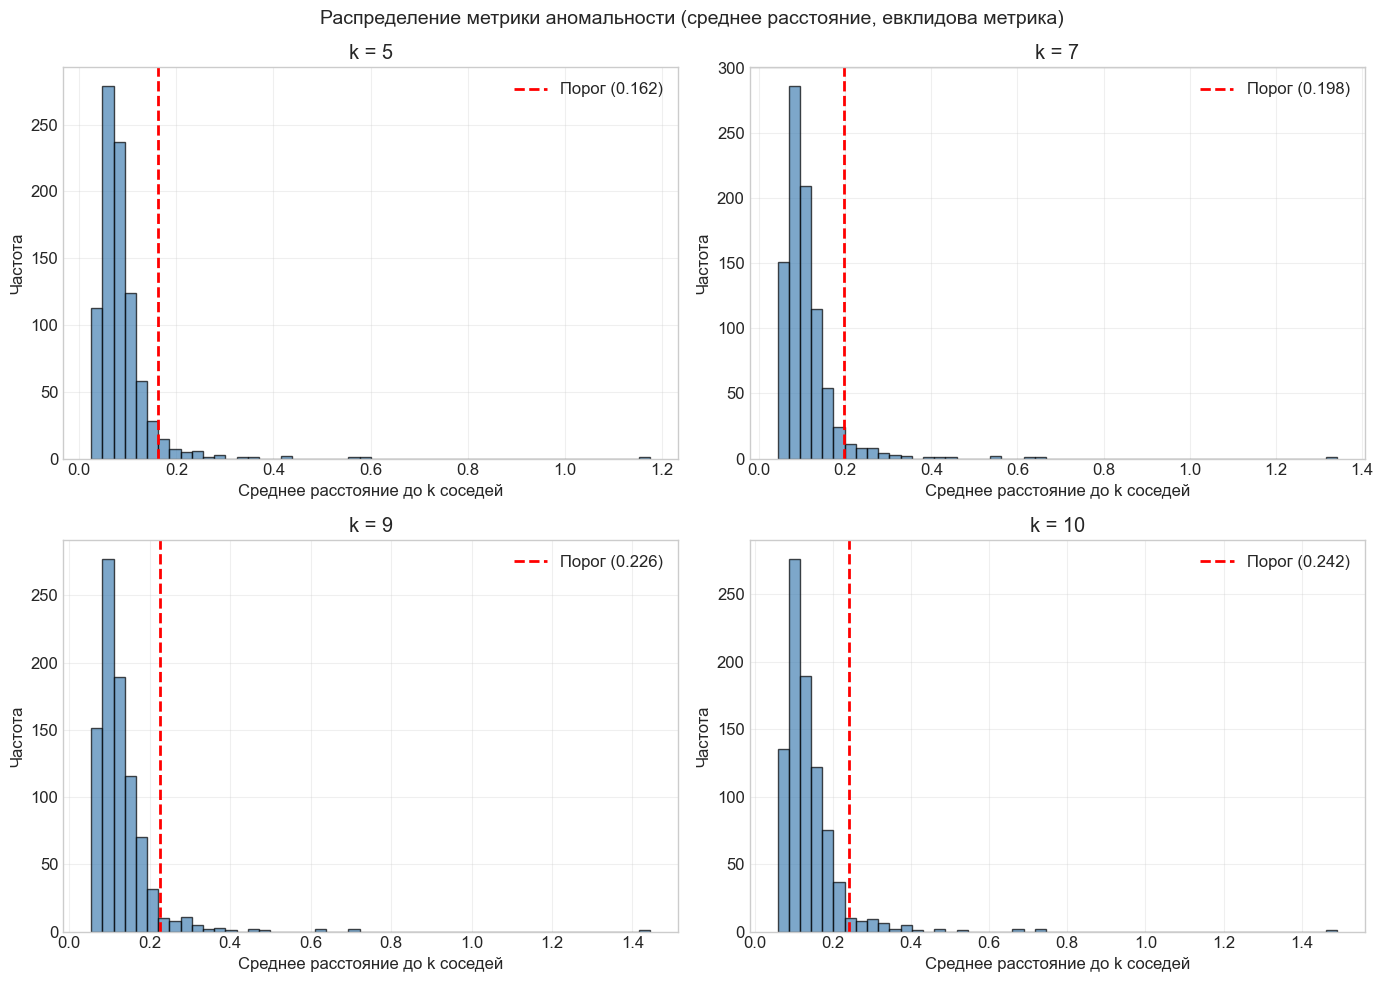

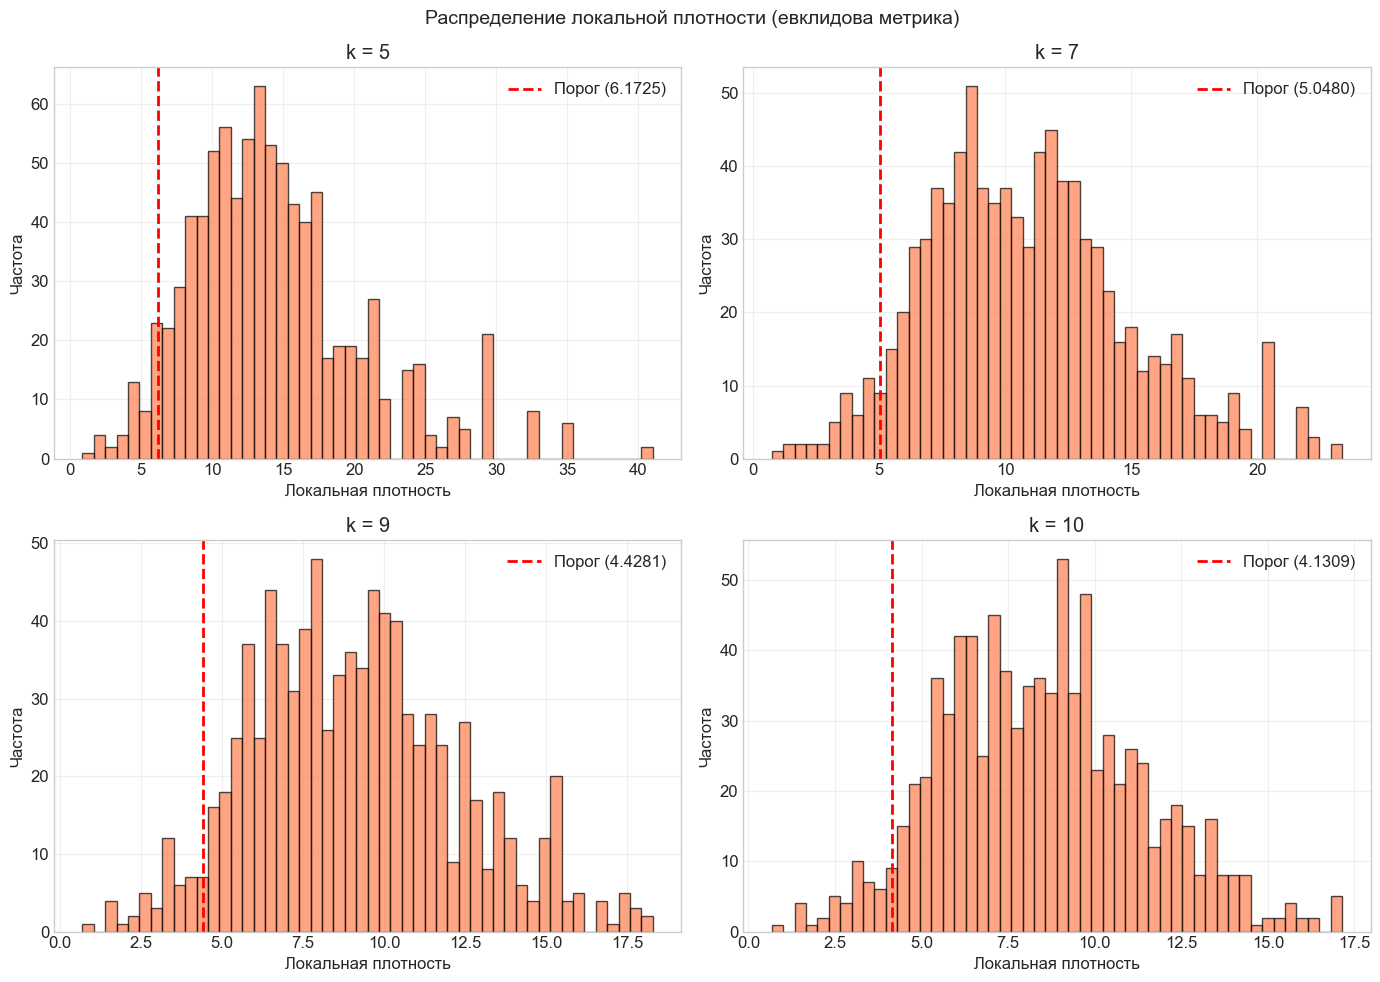

In [91]:
# Визуализация распределения метрики

# Восстанавливаем исходные данные для визуализации
df_original = pd.DataFrame(df_scaled, columns=features_knn)

# Гистограммы для среднего расстояния (евклидова метрика)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    results = mean_results_euclidean[k]
    
    axes[idx].hist(results['mean_distances'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    axes[idx].axvline(results['threshold'], color='red', linestyle='--', 
                      linewidth=2, label=f'Порог ({results["threshold"]:.3f})')
    axes[idx].set_title(f'k = {k}')
    axes[idx].set_xlabel('Среднее расстояние до k соседей')
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Распределение метрики аномальности (среднее расстояние, евклидова метрика)', fontsize=14)
plt.tight_layout()
plt.show()

# Гистограммы для локальной плотности (евклидова метрика)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    results = density_results['euclidean'][k]
    
    axes[idx].hist(results['density'], bins=50, alpha=0.7, edgecolor='black', color='coral')
    axes[idx].axvline(results['threshold'], color='red', linestyle='--', 
                      linewidth=2, label=f'Порог ({results["threshold"]:.4f})')
    axes[idx].set_title(f'k = {k}')
    axes[idx].set_xlabel('Локальная плотность')
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Распределение локальной плотности (евклидова метрика)', fontsize=14)
plt.tight_layout()
plt.show()

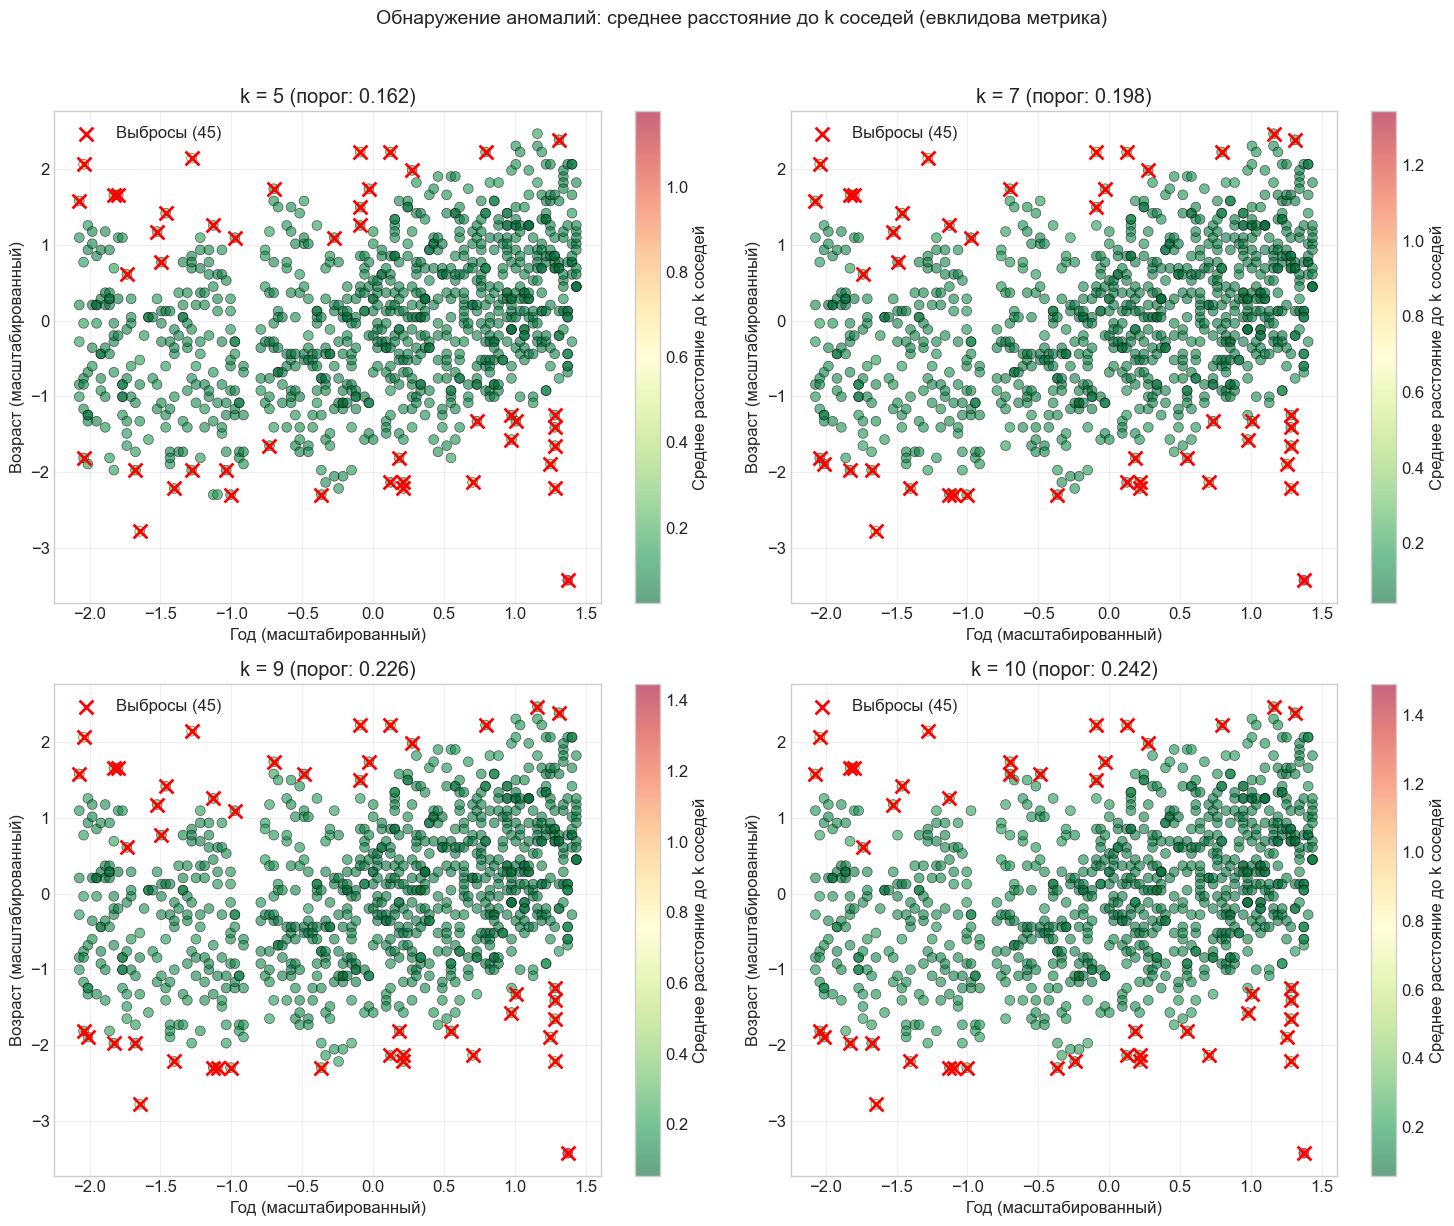

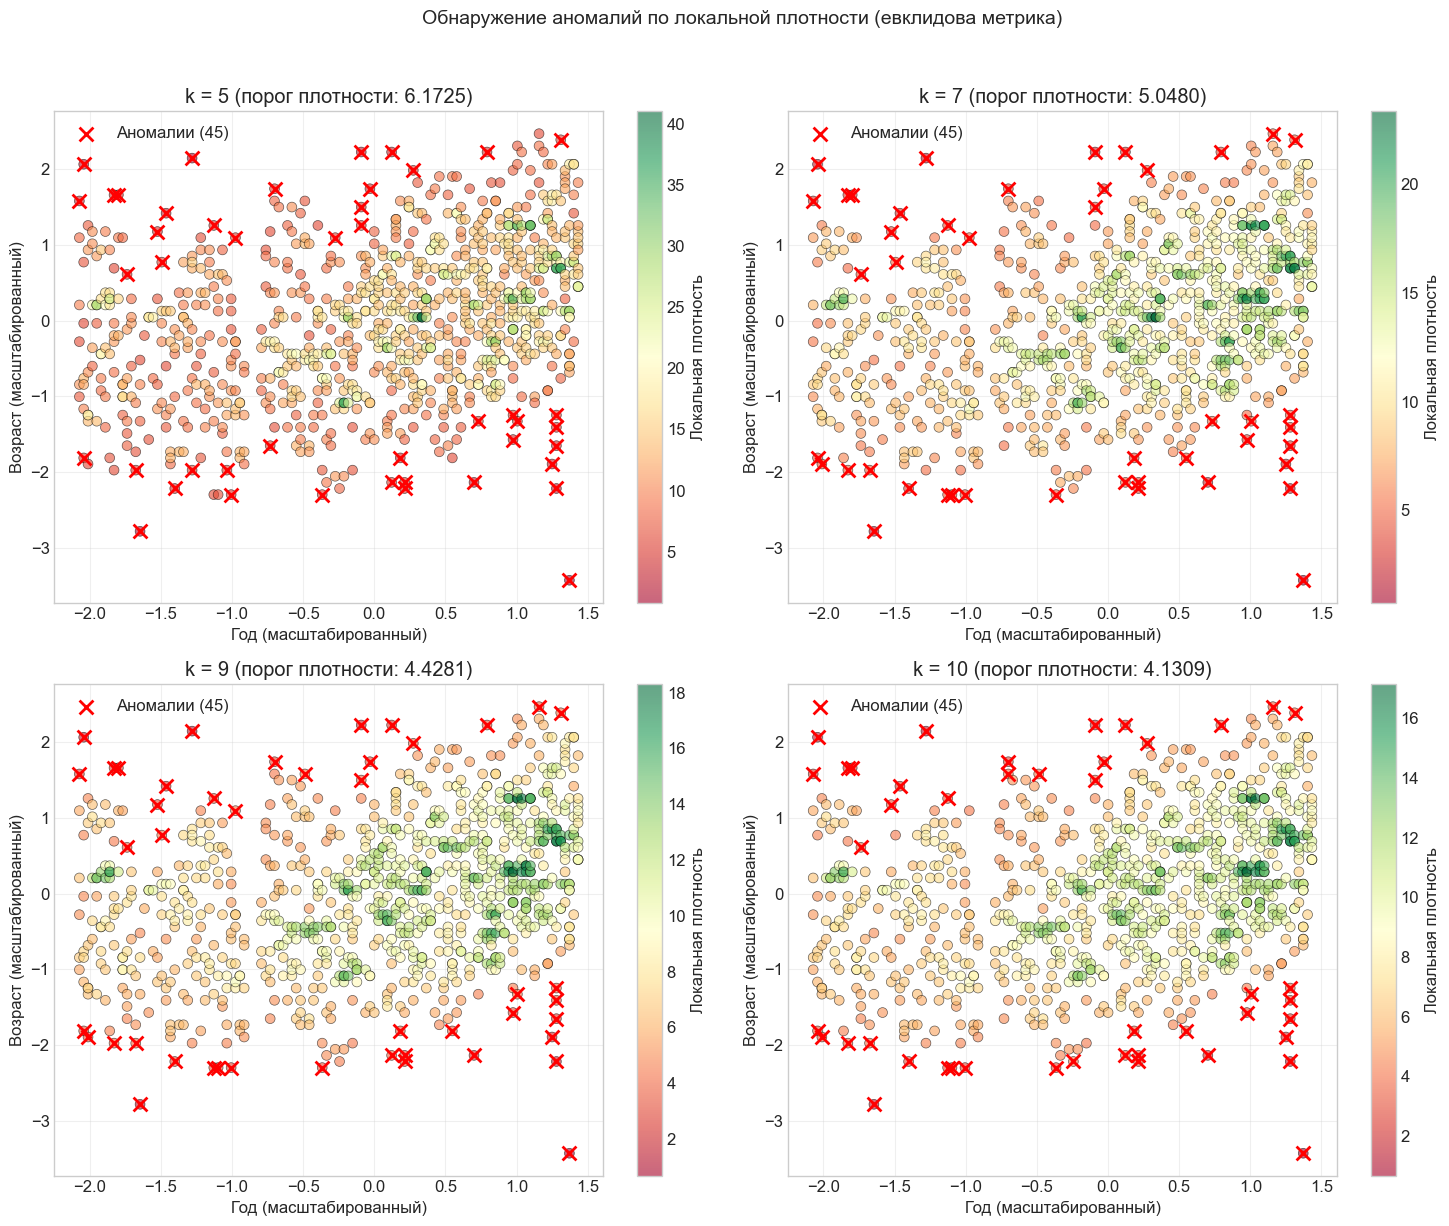

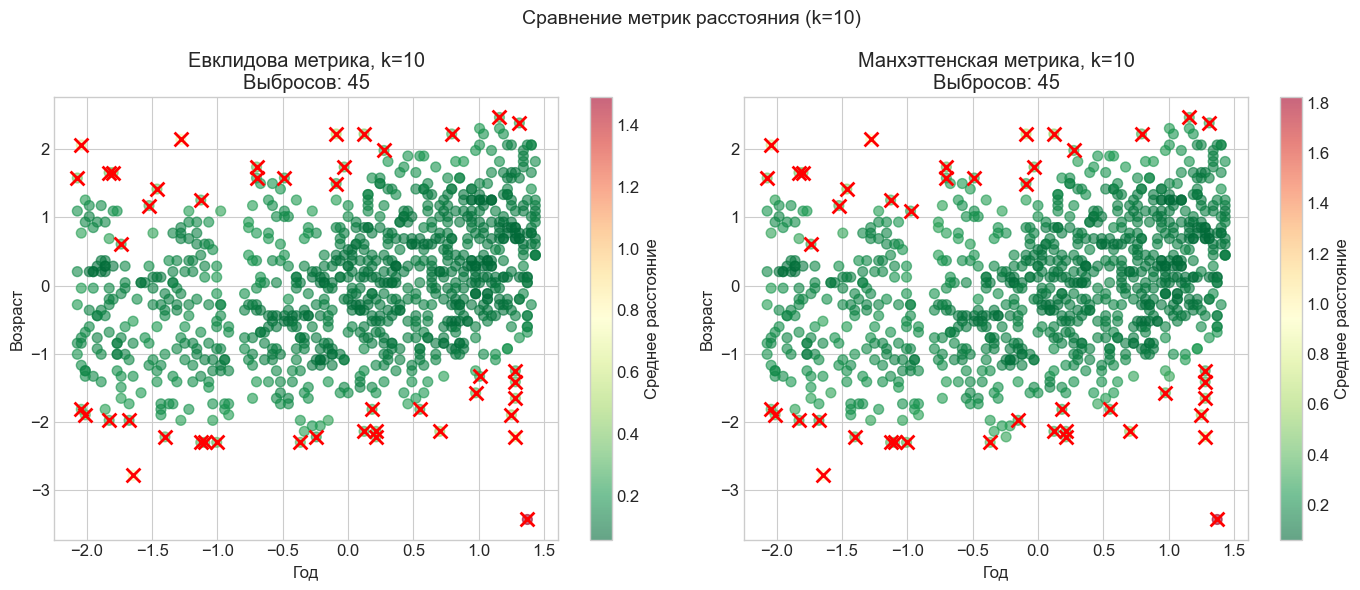

In [82]:
# Визуализация на scatter plot

# Для метода среднего расстояния (евклидова метрика)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    results = mean_results_euclidean[k]
    outliers_mask = results['outliers']
    
    # Scatter plot с цветовой кодировкой по степени аномальности
    scatter = axes[idx].scatter(df_original['year'], df_original['age'], 
                                c=results['mean_distances'], cmap='RdYlGn_r', 
                                s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Выделяем выбросы
    axes[idx].scatter(df_original.loc[outliers_mask, 'year'], 
                     df_original.loc[outliers_mask, 'age'],
                     c='red', s=100, marker='x', linewidths=2, label=f'Выбросы ({results["outliers_count"]})')
    
    axes[idx].set_title(f'k = {k} (порог: {results["threshold"]:.3f})')
    axes[idx].set_xlabel('Год (масштабированный)')
    axes[idx].set_ylabel('Возраст (масштабированный)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    plt.colorbar(scatter, ax=axes[idx], label='Среднее расстояние до k соседей')

plt.suptitle('Обнаружение аномалий: среднее расстояние до k соседей (евклидова метрика)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Для метода локальной плотности (евклидова метрика)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    results = density_results['euclidean'][k]
    outliers_mask = results['outliers']
    
    # Scatter plot с цветовой кодировкой по плотности
    scatter = axes[idx].scatter(df_original['year'], df_original['age'], 
                                c=results['density'], cmap='RdYlGn', 
                                s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Выделяем аномалии
    axes[idx].scatter(df_original.loc[outliers_mask, 'year'], 
                     df_original.loc[outliers_mask, 'age'],
                     c='red', s=100, marker='x', linewidths=2, label=f'Аномалии ({results["outliers_count"]})')
    
    axes[idx].set_title(f'k = {k} (порог плотности: {results["threshold"]:.4f})')
    axes[idx].set_xlabel('Год (масштабированный)')
    axes[idx].set_ylabel('Возраст (масштабированный)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    plt.colorbar(scatter, ax=axes[idx], label='Локальная плотность')

plt.suptitle('Обнаружение аномалий по локальной плотности (евклидова метрика)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Сравнение метрик на одном графике (для k=10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

k = 10

# Евклидова метрика
results_euc = mean_results_euclidean[k]
outliers_euc = results_euc['outliers']
scatter1 = axes[0].scatter(df_original['year'], df_original['age'], 
                           c=results_euc['mean_distances'], cmap='RdYlGn_r', s=50, alpha=0.6)
axes[0].scatter(df_original.loc[outliers_euc, 'year'], df_original.loc[outliers_euc, 'age'],
                c='red', s=100, marker='x', linewidths=2)
axes[0].set_title(f'Евклидова метрика, k={k}\nВыбросов: {results_euc["outliers_count"]}')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Возраст')
plt.colorbar(scatter1, ax=axes[0], label='Среднее расстояние')

# Манхэттенская метрика
results_man = mean_results_manhattan[k]
outliers_man = results_man['outliers']
scatter2 = axes[1].scatter(df_original['year'], df_original['age'], 
                           c=results_man['mean_distances'], cmap='RdYlGn_r', s=50, alpha=0.6)
axes[1].scatter(df_original.loc[outliers_man, 'year'], df_original.loc[outliers_man, 'age'],
                c='red', s=100, marker='x', linewidths=2)
axes[1].set_title(f'Манхэттенская метрика, k={k}\nВыбросов: {results_man["outliers_count"]}')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Возраст')
plt.colorbar(scatter2, ax=axes[1], label='Среднее расстояние')

plt.suptitle('Сравнение метрик расстояния (k=10)', fontsize=14)
plt.tight_layout()
plt.show()

In [83]:
# Анализ устойчивости метода при изменении k
print("АНАЛИЗ УСТОЙЧИВОСТИ МЕТОДА ПРИ ИЗМЕНЕНИИ k")

# Создаем сводную таблицу для сравнения
summary_data = []
for metric in ['euclidean', 'manhattan']:
    for k in k_values:
        summary_data.append({
            'Метрика': metric.upper(),
            'k': k,
            'Выбросов (ср. расстояние)': mean_results_euclidean[k]['outliers_count'] if metric == 'euclidean' else mean_results_manhattan[k]['outliers_count'],
            'Выбросов (k-й сосед)': kth_results_euclidean[k]['outliers_count'] if metric == 'euclidean' else kth_results_manhattan[k]['outliers_count'],
            'Аномалий (плотность)': density_results[metric][k]['outliers_count']
        })

summary_df = pd.DataFrame(summary_data)
print("\nСводная таблица результатов:")
print(summary_df.to_string(index=False))

# Анализ стабильности для каждого метода
print("Анализ стабильности (стандартное отклонение количества выбросов при разных k):")

for metric in ['euclidean', 'manhattan']:
    print(f"\n{metric.upper()} метрика:")
    
    mean_counts = [mean_results_euclidean[k]['outliers_count'] if metric == 'euclidean' else mean_results_manhattan[k]['outliers_count'] for k in k_values]
    kth_counts = [kth_results_euclidean[k]['outliers_count'] if metric == 'euclidean' else kth_results_manhattan[k]['outliers_count'] for k in k_values]
    density_counts = [density_results[metric][k]['outliers_count'] for k in k_values]
    
    print(f"  Среднее расстояние: среднее={np.mean(mean_counts):.1f}, std={np.std(mean_counts):.1f}")
    print(f"  Расстояние до k-го соседа: среднее={np.mean(kth_counts):.1f}, std={np.std(kth_counts):.1f}")
    print(f"  Локальная плотность: среднее={np.mean(density_counts):.1f}, std={np.std(density_counts):.1f}")

# Анализ пересечений выбросов при разных k
print("Пересечения выбросов при разных k (метод среднего расстояния, евклидова метрика):")

outliers_sets = {}
for k in k_values:
    outliers_sets[k] = set(np.where(mean_results_euclidean[k]['outliers'])[0])

# Пересечение всех k
common_outliers = outliers_sets[k_values[0]]
for k in k_values[1:]:
    common_outliers = common_outliers.intersection(outliers_sets[k])

print(f"Выбросы, общие для всех k ({len(common_outliers)} шт.): {sorted(list(common_outliers))[:10]}...")

# Попарные пересечения
print("\nПопарные пересечения выбросов:")
for i, k1 in enumerate(k_values):
    for k2 in k_values[i+1:]:
        intersection = outliers_sets[k1] & outliers_sets[k2]
        print(f"  k={k1} ∩ k={k2}: {len(intersection)} общих выбросов")

АНАЛИЗ УСТОЙЧИВОСТИ МЕТОДА ПРИ ИЗМЕНЕНИИ k

Сводная таблица результатов:
  Метрика  k  Выбросов (ср. расстояние)  Выбросов (k-й сосед)  Аномалий (плотность)
EUCLIDEAN  5                         45                    44                    45
EUCLIDEAN  7                         45                    44                    45
EUCLIDEAN  9                         45                    45                    45
EUCLIDEAN 10                         45                    45                    45
MANHATTAN  5                         44                    45                    44
MANHATTAN  7                         45                    44                    45
MANHATTAN  9                         45                    45                    45
MANHATTAN 10                         45                    44                    45
Анализ стабильности (стандартное отклонение количества выбросов при разных k):

EUCLIDEAN метрика:
  Среднее расстояние: среднее=45.0, std=0.0
  Расстояние до k-го соседа:

СРАВНЕНИЕ С КЛАССИЧЕСКИМИ МЕТОДАМИ

Количество выбросов по каждому методу:
  Z-score: 1
  IQR: 1
  kNN (евклидова, k=10): 45
  kNN (манхэттенская, k=10): 45

Пересечения методов (евклидова метрика):
  Z-score ∩ IQR: 1
  Z-score ∩ kNN: 1
  IQR ∩ kNN: 1
  Все три метода: 1

Пересечения методов (манхэттенская метрика):
  Z-score ∩ kNN: 1
  IQR ∩ kNN: 1
  Все три метода: 1


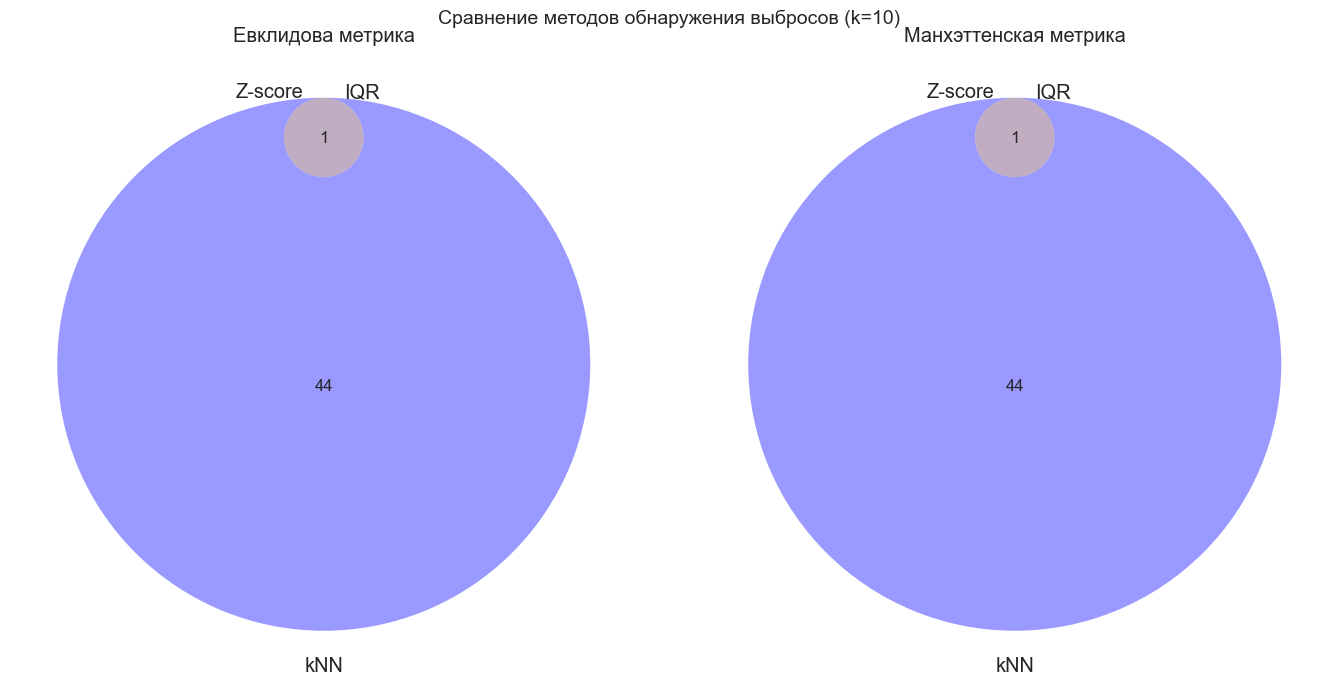

In [102]:
# Сравнение с классическими методами

print("СРАВНЕНИЕ С КЛАССИЧЕСКИМИ МЕТОДАМИ")

# Выбросы по kNN (k=10, евклидова метрика, метод среднего расстояния)
knn_outliers_set_euc = set(df_knn.iloc[np.where(mean_results_euclidean[10]['outliers'])[0]].index)
knn_outliers_set_man = set(df_knn.iloc[np.where(mean_results_manhattan[10]['outliers'])[0]].index)

print(f"\nКоличество выбросов по каждому методу:")
print(f"  Z-score: {len(outliers_z_set)}")
print(f"  IQR: {len(outliers_iqr_set)}")
print(f"  kNN (евклидова, k=10): {len(knn_outliers_set_euc)}")
print(f"  kNN (манхэттенская, k=10): {len(knn_outliers_set_man)}")

print("\nПересечения методов (евклидова метрика):")
print(f"  Z-score ∩ IQR: {len(outliers_z_set & outliers_iqr_set)}")
print(f"  Z-score ∩ kNN: {len(outliers_z_set & knn_outliers_set_euc)}")
print(f"  IQR ∩ kNN: {len(outliers_iqr_set & knn_outliers_set_euc)}")
print(f"  Все три метода: {len(outliers_z_set & outliers_iqr_set & knn_outliers_set_euc)}")

print("\nПересечения методов (манхэттенская метрика):")
print(f"  Z-score ∩ kNN: {len(outliers_z_set & knn_outliers_set_man)}")
print(f"  IQR ∩ kNN: {len(outliers_iqr_set & knn_outliers_set_man)}")
print(f"  Все три метода: {len(outliers_z_set & outliers_iqr_set & knn_outliers_set_man)}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
axes[0].set_title('Евклидова метрика')
venn3([outliers_z_set, outliers_iqr_set, knn_outliers_set_euc], 
    ('Z-score', 'IQR', 'kNN'), ax=axes[0])
    
axes[1].set_title('Манхэттенская метрика')
venn3([outliers_z_set, outliers_iqr_set, knn_outliers_set_man], 
        ('Z-score', 'IQR', 'kNN'), ax=axes[1])
    
plt.suptitle('Сравнение методов обнаружения выбросов (k=10)', fontsize=14)
plt.tight_layout()
plt.show()

In [79]:
# Интерпретация результатов и формирование выводов

print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")

# Анализ конкретных аномалий (топ-10)
print("\nТоп-10 наиболее аномальных точек (метод среднего расстояния, k=10, евклидова метрика):")

k_optimal = 10
results = mean_results_euclidean[k_optimal]
outliers_indices = np.where(results['outliers'])[0]

# Сортируем по степени аномальности
sorted_indices = np.argsort(results['mean_distances'])[::-1]

for rank, idx in enumerate(sorted_indices[:10], 1):
    mean_dist = results['mean_distances'][idx]
    original_data = df_knn.iloc[idx]
    
    print(f"\n{rank}. Индекс: {idx}")
    print(f"   Год: {original_data['year']:.0f}, Возраст: {original_data['age']:.1f}")
    print(f"   Мера аномальности: {mean_dist:.4f}")
    

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

Топ-10 наиболее аномальных точек (метод среднего расстояния, k=10, евклидова метрика):

1. Индекс: 858
   Год: 2014, Возраст: 17.0
   Мера аномальности: 1.4901

2. Индекс: 83
   Год: 1915, Возраст: 25.0
   Мера аномальности: 0.7253

3. Индекс: 133
   Год: 1927, Возраст: 86.0
   Мера аномальности: 0.7212

4. Индекс: 825
   Год: 2011, Возраст: 32.0
   Мера аномальности: 0.6661

5. Индекс: 7
   Год: 1902, Возраст: 85.0
   Мера аномальности: 0.6613

6. Индекс: 362
   Год: 1966, Возраст: 87.0
   Мера аномальности: 0.5196

7. Индекс: 815
   Год: 2010, Возраст: 36.0
   Мера аномальности: 0.4745

8. Индекс: 609
   Год: 1992, Возраст: 33.0
   Мера аномальности: 0.4669

9. Индекс: 419
   Год: 1973, Возраст: 87.0
   Мера аномальности: 0.4210

10. Индекс: 824
   Год: 2011, Возраст: 39.0
   Мера аномальности: 0.3921


## Выводы
1. Метрики расстояния:
   - Евклидова метрика: чувствительна к масштабу, хорошо работает для компактных кластеров.
     Обнаруживает глобальные выбросы, удаленные от основной массы точек.
   
   - Манхэттенская метрика: более робастна к выбросам, лучше работает в пространствах
     с высокой размерностью. Меньше чувствительна к аномальным значениям по отдельным признакам.

2. Влияние параметра k:
   - Маленькие k (5-7): метод более чувствителен к локальным аномалиям, может обнаруживать
     больше выбросов, но также и ложные срабатывания.
   
   - Большие k (9-10): сглаживают локальные флуктуации, находят глобальные аномалии,
     более устойчивы к шуму.
   
   - Рекомендуемое значение: k = 7-10 (оптимальный баланс чувствительности и устойчивости).

3. Сравнение подходов:
   - Расстояние до k-го соседа: простой, но чувствительный к выбросам метод.
   - Среднее расстояние до k соседей: более устойчивая метрика, предпочтительнее для реальных данных.
   - Локальная плотность: лучше работает при неравномерной плотности распределения данных.

4. Сравнение с классическими методами:
   - Методы на основе плотности обнаруживают многомерные аномалии, которые могут быть не видны
     при одномерном анализе (Z-score, IQR).
   - Классические методы лучше работают с одномерными выбросами.
